# A Hierarchical Model of Honeybee Waggle-Dances
---

## Details

&ensp;AUTHOR:&emsp;   James Foster &emsp; 2025 03 14

MODIFIED:&emsp; James Foster &emsp; 2026 04 14

DESCRIPTION:&emsp; Fit a hierarchical maximum-likelihood von Mises to honeybee waggle-run angles.
Modified from [beetles.ipynb](https://github.com/jgraving/unwrap/notebooks/)

            
INPUTS:&emsp;   `'colour_dance_reorg.csv'`
            
OUTPUTS:&emsp;  Plots and test statistics

CHANGES: 
- 

REFERENCES:
- Sayin S, ... Graving JM, $et~al$. (2025)
The behavioral mechanisms governing collective motion in swarming locusts.
Science 387,995-1000
DOI:[10.1126/science.adq7832](https://doi.org/10.1126/science.adq7832)

- Graving JM & Foster JJ in preparation
Unwrapping Circular Statistics: Bayesian Linear Models for Circular Data

---

## To Do list
>- Fix path to data +
>- Set up `GUV_model_all.Rmd` equivalent +
>- Run model +
- Extract predictions
- Build hypothesis tests
- Plot hypothesis tests

# First set up the required packages
Don't forget to make sure the the kernel is running in a `conda` environment.
To fit models using `g++` (recommended for speed) make sure `m2w64-toolchain` is installed on Windows.

In [134]:
#set up required packages
##JJF make sure to select a conda environment as the kernel!
##JJF to use g++, before running: conda install m2w64-toolchain
##JJF on Mac install "ipywidgets" for Jupyter support of PyMC
#20260413 skipping until numpy 2.0 issues are resolved
    # import sys
    # !{sys.executable} -m pip uninstall -y unwrap
    # !{sys.executable} -m pip install -U --no-cache git+https://github.com/jgraving/unwrap 

# Prepare the data
## Import and format the data
Load the preprocessed data from CSV and convert to radians. Relabel the two conditions in each factor to binary.

In [135]:

import pandas as pd
import numpy as np
from unwrap.link.numpy import shifted_modulo

# Load the file
file_path = '1Data/colour_dance_reorg.csv'#JJF windows is having trouble finding this file
df = pd.read_csv(file_path, sep=',')

# Create a binary indicator for the light intensity (1 for 'low', 0 for 'high')
df['B'] = df['brightn'].apply(lambda x: 1 if 'l' in x else 0)
# Create a binary indicator for the light colour (1 for 'UV', 0 for 'green')
df['C'] = df['colour'].apply(lambda x: 1 if 'u' in x else 0)
# Rename sun azimuth to use capitalised label
df['SunAz'] = df['sun_az_rad']
# Rename run to use capitalised label
df['Run'] = df['run']

# Convert the dance angle column to the correct format (already radians?)
df['angle'] = pd.to_numeric(df['angle'], errors='coerce')  # Convert non-numeric values (e.g., 'NA') to NaN

# Normalise all angles to be between -pi and pi (should be already)
df['angle'] = df['angle'].apply(lambda x: shifted_modulo(x) if pd.notnull(x) else x)
df['sun_az_rad'] = df['sun_az_rad'].apply(lambda x: shifted_modulo(x) if pd.notnull(x) else x)

# Keep only the relevant columns and drop rows with missing values
df = df[['angle','ID', 'B', 'C', 'Run','SunAz']].dropna().copy()
df.reset_index(drop=True, inplace=True)

# Rename columns: change 'Beetle' to 'Individual'
df = df.rename(columns={'ID': 'Individual'})
df['Individual'] = df['Individual'].astype('category')

df.head()

,angle,Individual,B,C,Run,SunAz
0,1.570796,2016.05.31.14.24,1,1,1,-2.647205
1,-0.087266,2016.05.31.14.24,1,1,2,-2.647205
2,-0.349066,2016.05.31.14.24,1,1,3,-2.647205
3,0.698132,2016.05.31.14.24,1,1,4,-2.647205
4,-0.349066,2016.05.31.14.24,1,1,5,-2.647205


## Inspect the data
Use Jake's plots to show the repeated angles across individuals.
Maybe limit this to just 10 individuals for now.

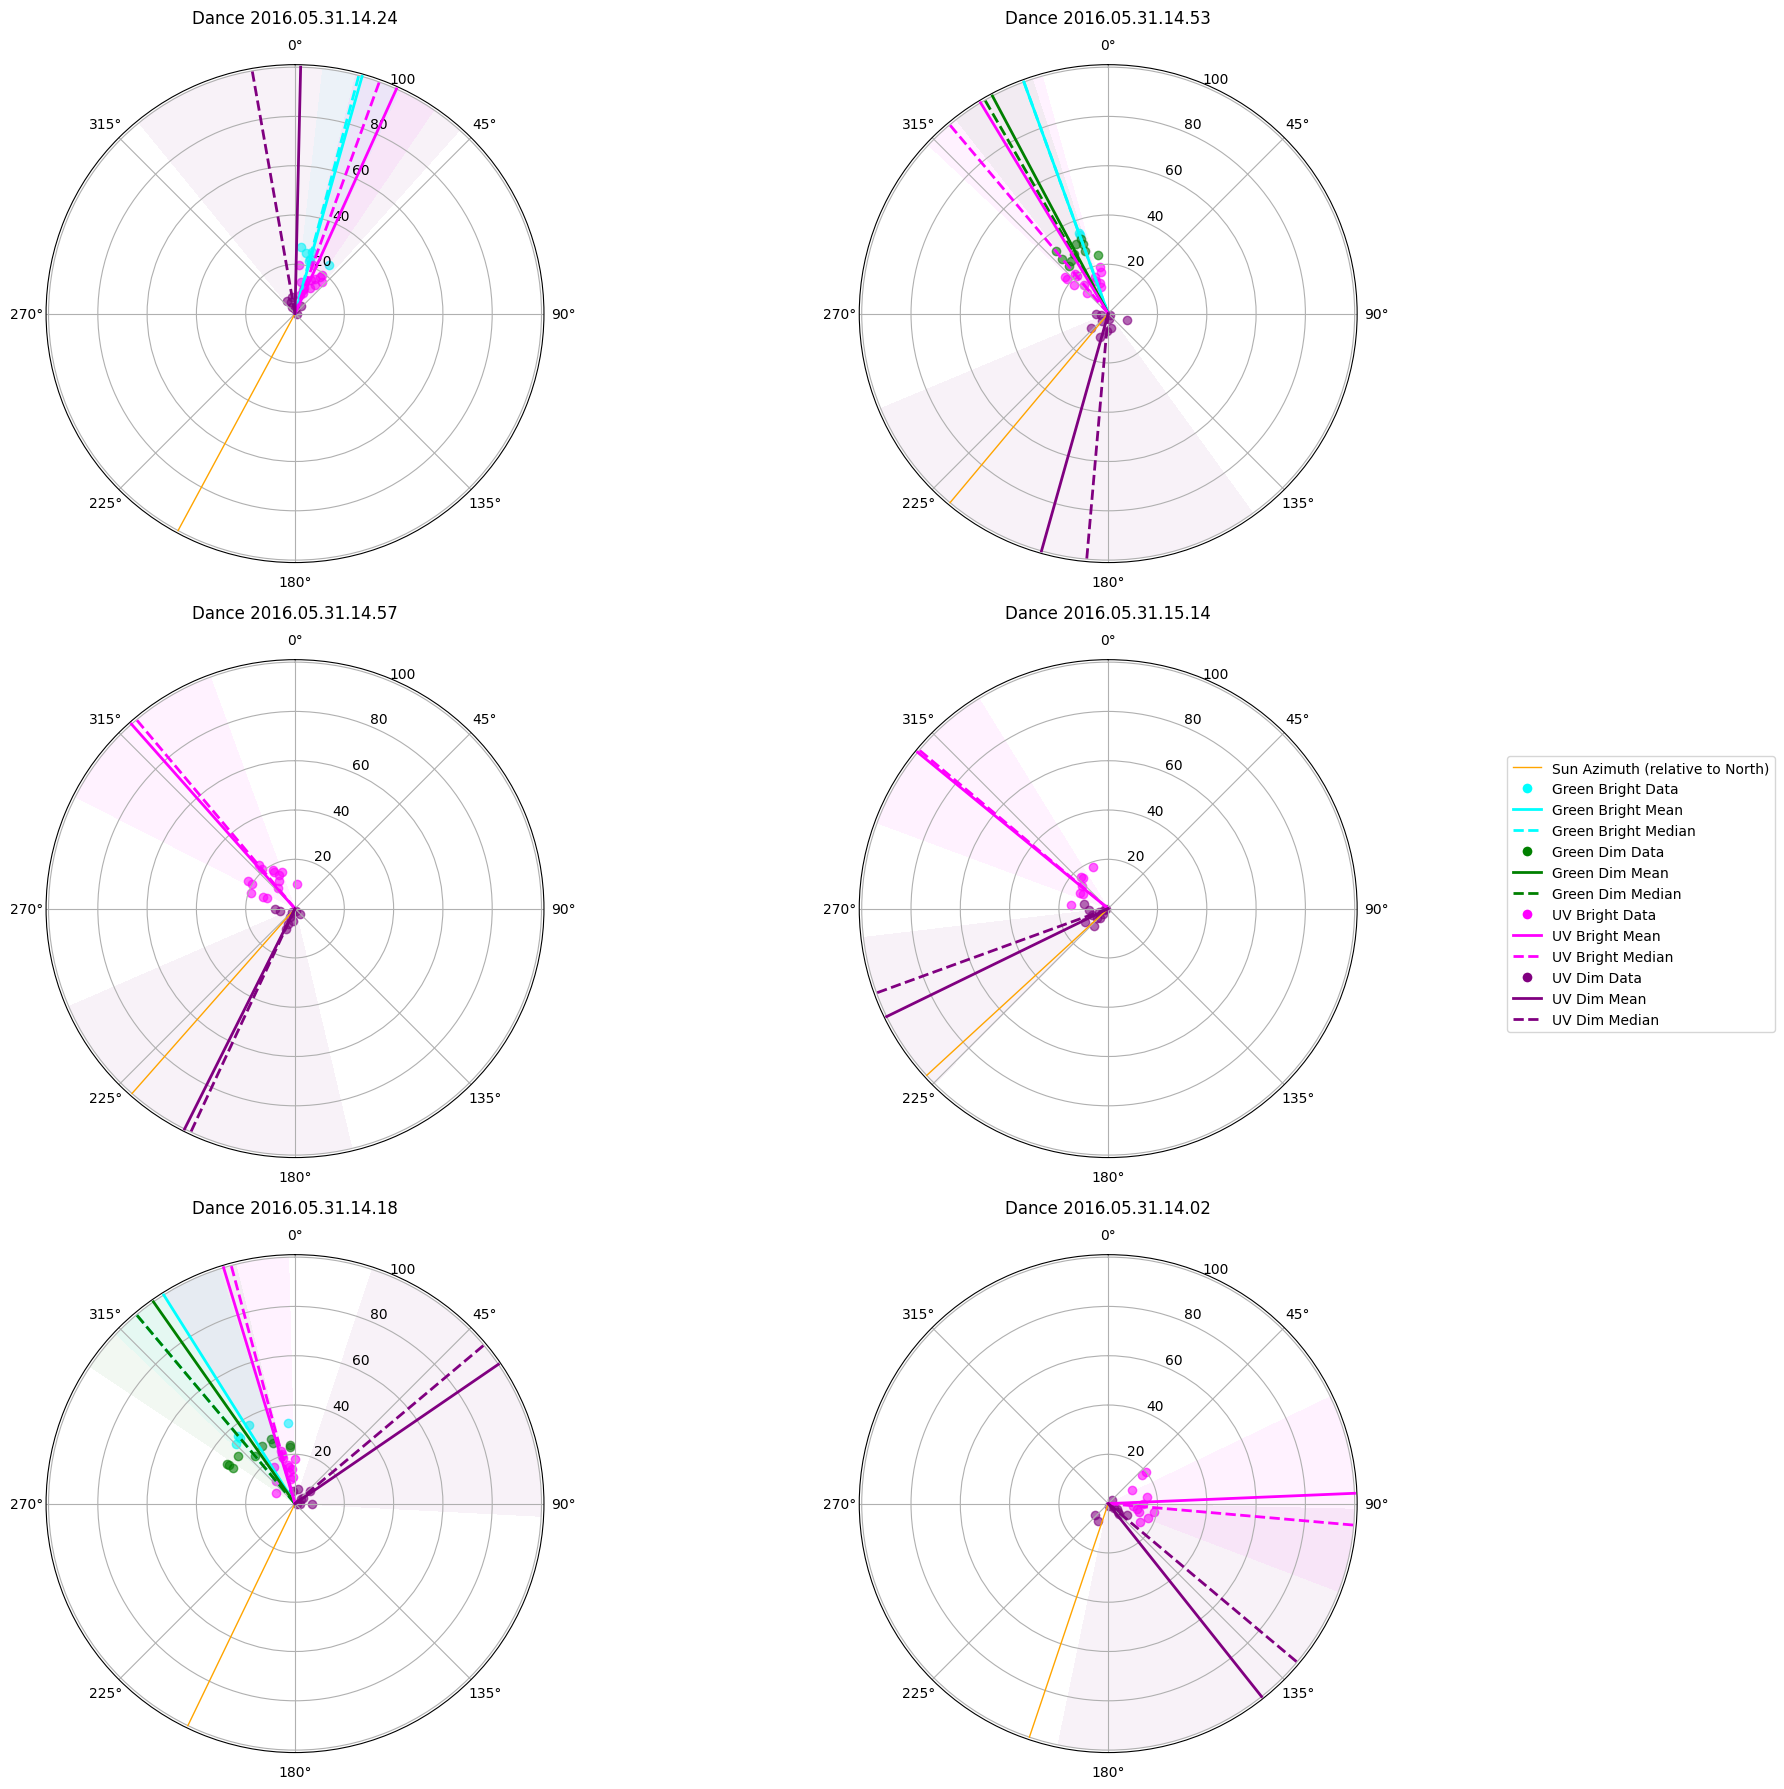

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd
from matplotlib.lines import Line2D

# Helper function to compute the circular median.
def circ_median(angles):
    angles = np.sort(angles)
    diffs = np.abs(np.angle(np.exp(1j * (angles[:, None] - angles[None, :]))))
    sum_diffs = np.sum(diffs, axis=1)
    return angles[np.argmin(sum_diffs)]

# Helper function to scatter-plot data for one condition.
def plot_scatter(ax, data, angle_col, radial_col, color, label):
    if not data.empty:
        ax.scatter(data[angle_col], data[radial_col],
                   color=color, alpha=0.6, label=label)

# Helper function to compute and plot summary statistics.
# It plots a solid vertical line at the circular mean and a dashed vertical line at the circular median,
# both in the specified color. It also fills the region ± the circular standard deviation.
def plot_summary_stats(ax, angles, radial_max, color):
    # Compute circular mean, median, and standard deviation.
    mean_val = circmean(angles, high=np.pi, low=-np.pi)
    median_val = circ_median(angles)
    std_val = circstd(angles, high=np.pi, low=-np.pi, normalize=True)
    
    # Plot mean (solid) and median (dashed).
    ax.plot([mean_val, mean_val], [0, radial_max], color=color, linewidth=2)
    ax.plot([median_val, median_val], [0, radial_max], color=color, linewidth=2, linestyle='--')
    
    # Fill the region between mean minus std and mean plus std.
    theta_vals = np.linspace(mean_val - std_val, mean_val + std_val, 100)
    r_vals = np.linspace(0, radial_max, 100)
    Theta, R = np.meshgrid(theta_vals, r_vals)
    ax.contourf(Theta, R, np.ones_like(Theta), alpha=0.05, colors=[color]) # was alpha = 0.2, but covers too much data
    
    return mean_val, median_val, std_val

# Get unique individual IDs.
unique_individuals = df['Individual'].unique()
unique_individuals = unique_individuals[range(0,6)] # for now just the 1st 6 

# Create a grid of polar subplots.
n_plots = len(unique_individuals)
n_rows, n_cols = ( np.intc(n_plots/2) , 2  ) # Adjust grid dimensions as needed.
fig, axes = plt.subplots(n_rows, n_cols, subplot_kw={'projection': 'polar'}, figsize=(18, np.intc(n_plots*3)))
axes = axes.flatten()

# radial_max = 10*4  # Maximum radial value
radial_max = np.max(df['Run'])  # Maximum radial value (maximum runs)

# Plot for each individual.
for idx, individual in enumerate(unique_individuals):
    ax = axes[idx]
    # Set axes to geographic format (clockwise, 0° at the top)
    ax.set_theta_direction(-1)#reverse to clockwise
    ax.set_theta_zero_location('N')#place 0° at the top
    individual_data = df[df['Individual'] == individual]
    
    # Separate Light bright and Light dim data (drop NaNs in angle).
    data_on = individual_data[individual_data['B'] == 0].dropna(subset=['angle'])
    data_off = individual_data[individual_data['B'] == 1].dropna(subset=['angle'])
    # Separate bright data.
    data_gh = data_on[data_on['C'] == 0]
    data_uh = data_on[data_on['C'] == 1]
    # Separate dim data.
    data_gl = data_off[data_off['C'] == 0]
    data_ul = data_off[data_off['C'] == 1]
    
    # Scatter-plot data.
    plot_scatter(ax, data_gh, 'angle', 'Run', 'cyan', 'Green Bright')
    plot_scatter(ax, data_gl, 'angle', 'Run', 'green', 'Green Dim')
    plot_scatter(ax, data_uh, 'angle', 'Run', 'magenta', 'UV Bright')
    plot_scatter(ax, data_ul, 'angle', 'Run', 'purple', 'UV Dim')
    
    #Plot the sun's azimuth for reference
    ax.plot(individual_data['SunAz'].values[range(0,2)], [0, radial_max], color='orange', linewidth=1)
    # Plot summary statistics for each condition.
    if not data_gh.empty:
        plot_summary_stats(ax, data_gh['angle'].values, radial_max, 'cyan')
    if not data_gl.empty:
        plot_summary_stats(ax, data_gl['angle'].values, radial_max, 'green')
    if not data_uh.empty:
        plot_summary_stats(ax, data_uh['angle'].values, radial_max, 'magenta')
    if not data_ul.empty:
        plot_summary_stats(ax, data_ul['angle'].values, radial_max, 'purple')
    
    ax.set_title(f'Dance {individual}', pad=30)
    ax.set_ylim(0, radial_max + 1)
    # Remove individual legends from each subplot.
    ax.legend().set_visible(False)

# Create a shared custom legend.
legend_handles = [
    # For sun azimuth (orange)
    Line2D([0], [0], color = 'orange', lw = 1, label = 'Sun Azimuth (relative to North)'),
    # For green bright (cyan)
    Line2D([0], [0], marker='o', color='w', markerfacecolor='cyan', markersize=8, label='Green Bright Data'),
    Line2D([0], [0], color='cyan', lw=2, label='Green Bright Mean'),
    Line2D([0], [0], color='cyan', lw=2, linestyle='--', label='Green Bright Median'),
    # For green dim (green)
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Green Dim Data'),
    Line2D([0], [0], color='green', lw=2, label='Green Dim Mean'),
    Line2D([0], [0], color='green', lw=2, linestyle='--', label='Green Dim Median'),
    # For UV bright (magenta)
    Line2D([0], [0], marker='o', color='w', markerfacecolor='magenta', markersize=8, label='UV Bright Data'),
    Line2D([0], [0], color='magenta', lw=2, label='UV Bright Mean'),
    Line2D([0], [0], color='magenta', lw=2, linestyle='--', label='UV Bright Median'),
    # For UV dim (purple)
    Line2D([0], [0], marker='o', color='w', markerfacecolor='purple', markersize=8, label='UV Dim Data'),
    Line2D([0], [0], color='purple', lw=2, label='UV Dim Mean'),
    Line2D([0], [0], color='purple', lw=2, linestyle='--', label='UV Dim Median'),
]

# Add one shared legend to the right of the figure.
fig.legend(handles=legend_handles, loc='center right', bbox_to_anchor=(1.10, 0.5), fontsize='medium')

plt.tight_layout()
plt.show()

# Fit a circular model with individual effects but no interactions
To begin with fit a model with only the effects of different individuals, light intensities and LED colours.
Goals for priors
- tighten for convergence   +
    - LogNormal for kappa sigma -> better without
    - HalfStudentT larger sd for kappa sigma    +
- loosen for accuracy
    - loosen kappamu b:c
    - loosen mu intercept
    - loosen mu b

In [137]:
import numpy as np
import pandas as pd
import bambi as bmb
import arviz as az
import matplotlib.pyplot as plt

from unwrap.link.bambi import LINKS
from unwrap.link.numpy import inverse_softplus
from unwrap.prior import CircularUniformPrior
from pymc import VonMises

from scipy.stats import vonmises, circstd

# Define the model formula with updated, capitalized variable names.
formula = bmb.Formula(
    "angle ~ B + C + B:C + (1 + B + C + B:C |Individual)",
    "kappa ~ B + C + B:C + (1 + B + C + B:C |Individual)",
)


# Specify priors for the model with capitalized keys and updated variable names.
priors = {
    # Fixed effects for μ:
    # "Intercept": bmb.Prior("Normal", mu=0, sigma=np.pi/6), # Works
    # "B": bmb.Prior("Normal", mu=0, sigma=np.pi/12), # Works
    # "C": bmb.Prior("Normal", mu=0, sigma=np.pi/12), # Works
    # "B:C": bmb.Prior("Normal", mu=0, sigma=np.pi/12), # Works
    "Intercept": bmb.Prior("Normal", mu=0, sigma=np.pi/4), # Test
    "B": bmb.Prior("Normal", mu=0, sigma=np.pi/9), # Test
    "C": bmb.Prior("Normal", mu=0, sigma=np.pi/9), # Test
    "B:C": bmb.Prior("Normal", mu=0, sigma=np.pi/9), # Test
    # Individual-level effects for μ: #bias to high kappa appears to cause divergent transitions here; large sigma slows estimation; mu=log(30), sigma=0.1 appears to be a good compromise.
    "1|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.60) # Informative prior, individuals close to pop mean circsd ~10° # do not change!
    ),
    "B|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.10) # Informative prior but long tails, individuals respond to brightness in the same way
    ),
    "C|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.10) # Informative prior but long tails, individuals respond to colour in the same way # try tightening
    ),
    # "B:C|Individual": bmb.Prior(
    #     "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(30), sigma=0.10) # Informative prior but long tails, individuals respond to colour in the same way # try tightening
    # ),#this works
    "B:C|Individual": bmb.Prior(
        "VonMises", mu=0, kappa=bmb.Prior("LogNormal", mu=np.log(10), sigma=0.10) # Informative prior but long tails, individuals respond to colour in the same way # try tightening
    ),#Test
    # Priors for the κ-model (inside the "kappa" dictionary):
    "kappa": {
        # Fixed effects for κ:
        # "Intercept": bmb.Prior("Normal", mu=inverse_softplus(3), sigma=0.5), # Works
        # "B": bmb.Prior("Normal", mu=0, sigma=0.3), # Works
        # "C": bmb.Prior("Normal", mu=0, sigma=0.3), # Works
        # "B:C": bmb.Prior("Normal", mu=0, sigma=1.0), # Works
        "Intercept": bmb.Prior("Normal", mu=inverse_softplus(3), sigma=0.5), # Test
        "B": bmb.Prior("Normal", mu=0, sigma=0.3), # Test
        "C": bmb.Prior("Normal", mu=0, sigma=0.3), # Test
        "B:C": bmb.Prior("Normal", mu=0, sigma=0.3), # Test
        # Individual-level effects for κ:
        # "1|Individual": bmb.Prior(
        #     "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.5) #Works
        # ),
        # "B|Individual": bmb.Prior(
        #     "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.5) #Works
        # ),
        # "C|Individual": bmb.Prior(
        #     "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.5) #Works
        # ),
        # "B:C|Individual": bmb.Prior(
        #     "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.5) #Works
        # ),
        "1|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.3) #Works
        ),
        "B|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.2) #Works
        ),
        "C|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.2) #Works
        ),
        "B:C|Individual": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfStudentT", nu=3, sigma=0.2) #Works
        ),
    },
}

# Build the model using the updated formula and priors.
model = bmb.Model(
    formula,
    df,
    family="vonmises",
    priors=priors,
    link={"mu": LINKS["shifted_modulo"], "kappa": LINKS["softplus"]},
    center_predictors=False,
    dropna=True,
)

print(model)

# Fit the model.
idata = model.fit(draws=1000,
                  tune = 1000,
                  progressbar="split+stats",
                  idata_kwargs={"log_likelihood": True},
                  target_accept= 0.90  # Needs sampling with small steps
        ) # be prepared for this to take 15 minutes

       Formula: angle ~ B + C + B:C + (1 + B + C + B:C |Individual)
                kappa ~ B + C + B:C + (1 + B + C + B:C |Individual)
        Family: vonmises
          Link: mu = shifted_modulo
                kappa = softplus
  Observations: 6118
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 0.7854)
            B ~ Normal(mu: 0.0, sigma: 0.3491)
            C ~ Normal(mu: 0.0, sigma: 0.3491)
            B:C ~ Normal(mu: 0.0, sigma: 0.3491)
        
        Group-level effects
            1|Individual ~ VonMises(mu: 0.0, kappa: LogNormal(mu: 3.4012, sigma: 0.6))
            B|Individual ~ VonMises(mu: 0.0, kappa: LogNormal(mu: 3.4012, sigma: 0.1))
            C|Individual ~ VonMises(mu: 0.0, kappa: LogNormal(mu: 3.4012, sigma: 0.1))
            B:C|Individual ~ VonMises(mu: 0.0, kappa: LogNormal(mu: 2.3026, sigma: 0.1))
    target = kappa
        Common-level effects
            kappa_Intercept ~ Normal(mu: 2.9489, sigma

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, B, C, B:C, 1|Individual_kappa, 1|Individual, B|Individual_kappa, B|Individual, C|Individual_kappa, C|Individual, B:C|Individual_kappa, B:C|Individual, kappa_Intercept, kappa_B, kappa_C, kappa_B:C, kappa_1|Individual_sigma, kappa_1|Individual_offset, kappa_B|Individual_sigma, kappa_B|Individual_offset, kappa_C|Individual_sigma, kappa_C|Individual_offset, kappa_B:C|Individual_sigma, kappa_B:C|Individual_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4865 seconds.
There were 65 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## Check convergence heuristics



In [138]:
#check convergence heuristics
az.summary(
    idata, 
    var_names=["Intercept", #slightly right shifted, should converge to around 0.26
               "B", 
                "C",
                "B:C",
                "kappa_Intercept",
               "kappa_B",
                "kappa_C",
                "kappa_B:C",
                ],
    circ_var_names=["Intercept",
                    "B",
                    "C",
                    "B:C",
                    ]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.181,0.083,0.029,0.355,0.007,0.004,134.0,243.0,1.03
B,-0.486,0.072,-0.621,-0.357,0.001,0.001,768.0,1677.0,1.00
C,0.078,0.038,0.005,0.144,0.002,0.001,915.0,1580.0,1.01
B:C,-1.107,0.101,-1.290,-0.918,0.004,0.002,533.0,588.0,1.01
kappa_Intercept,5.488,0.272,4.989,5.981,0.009,0.005,942.0,1494.0,1.00
kappa_B,-2.243,0.310,-2.866,-1.683,0.010,0.008,878.0,1444.0,1.01
kappa_C,1.560,0.214,1.132,1.932,0.006,0.003,1377.0,2397.0,1.01
kappa_B:C,-1.421,0.260,-1.899,-0.928,0.007,0.005,1235.0,1610.0,1.00


In [ ]:
#check convergence heuristics on random effects
az.summary(
    idata, 
    var_names=[
        "1|Individual_kappa",
        "B|Individual_kappa",
        "C|Individual_kappa",
        "B:C|Individual_kappa",
        "kappa_1|Individual_sigma",
        "kappa_B|Individual_sigma",
        "kappa_C|Individual_sigma",
        "kappa_B:C|Individual_sigma",
                ],
    # filter_vars='like',
    # circ_var_names=[]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
1|Individual_kappa,1.607,0.153,1.319,1.887,0.004,0.003,1682.0,1726.0,1.01
B|Individual_kappa,24.550,2.514,19.705,29.049,0.065,0.040,1477.0,2213.0,1.00
C|Individual_kappa,29.686,2.865,23.999,34.721,0.087,0.062,1120.0,895.0,1.00
B:C|Individual_kappa,3.585,0.282,3.106,4.167,0.011,0.006,680.0,1513.0,1.00
kappa_1|Individual_sigma,2.199,0.235,1.777,2.656,0.010,0.005,504.0,1339.0,1.01
kappa_B|Individual_sigma,3.241,0.580,2.168,4.316,0.029,0.014,403.0,964.0,1.01
kappa_C|Individual_sigma,0.322,0.299,0.000,0.922,0.016,0.012,452.0,610.0,1.01
kappa_B:C|Individual_sigma,2.923,0.486,2.106,3.857,0.023,0.014,470.0,818.0,1.01


## Visualise output of simple model

- The "Intercept" is the condition: **Green, Bright**
- B is the effect dimming the light: **Green, Dim**
- C is the effect of switching to UV: **UV, Bright**
- B:C is the effect of switching to UV-dim, compared to UV-bright and green-dim: **UV, Dim**

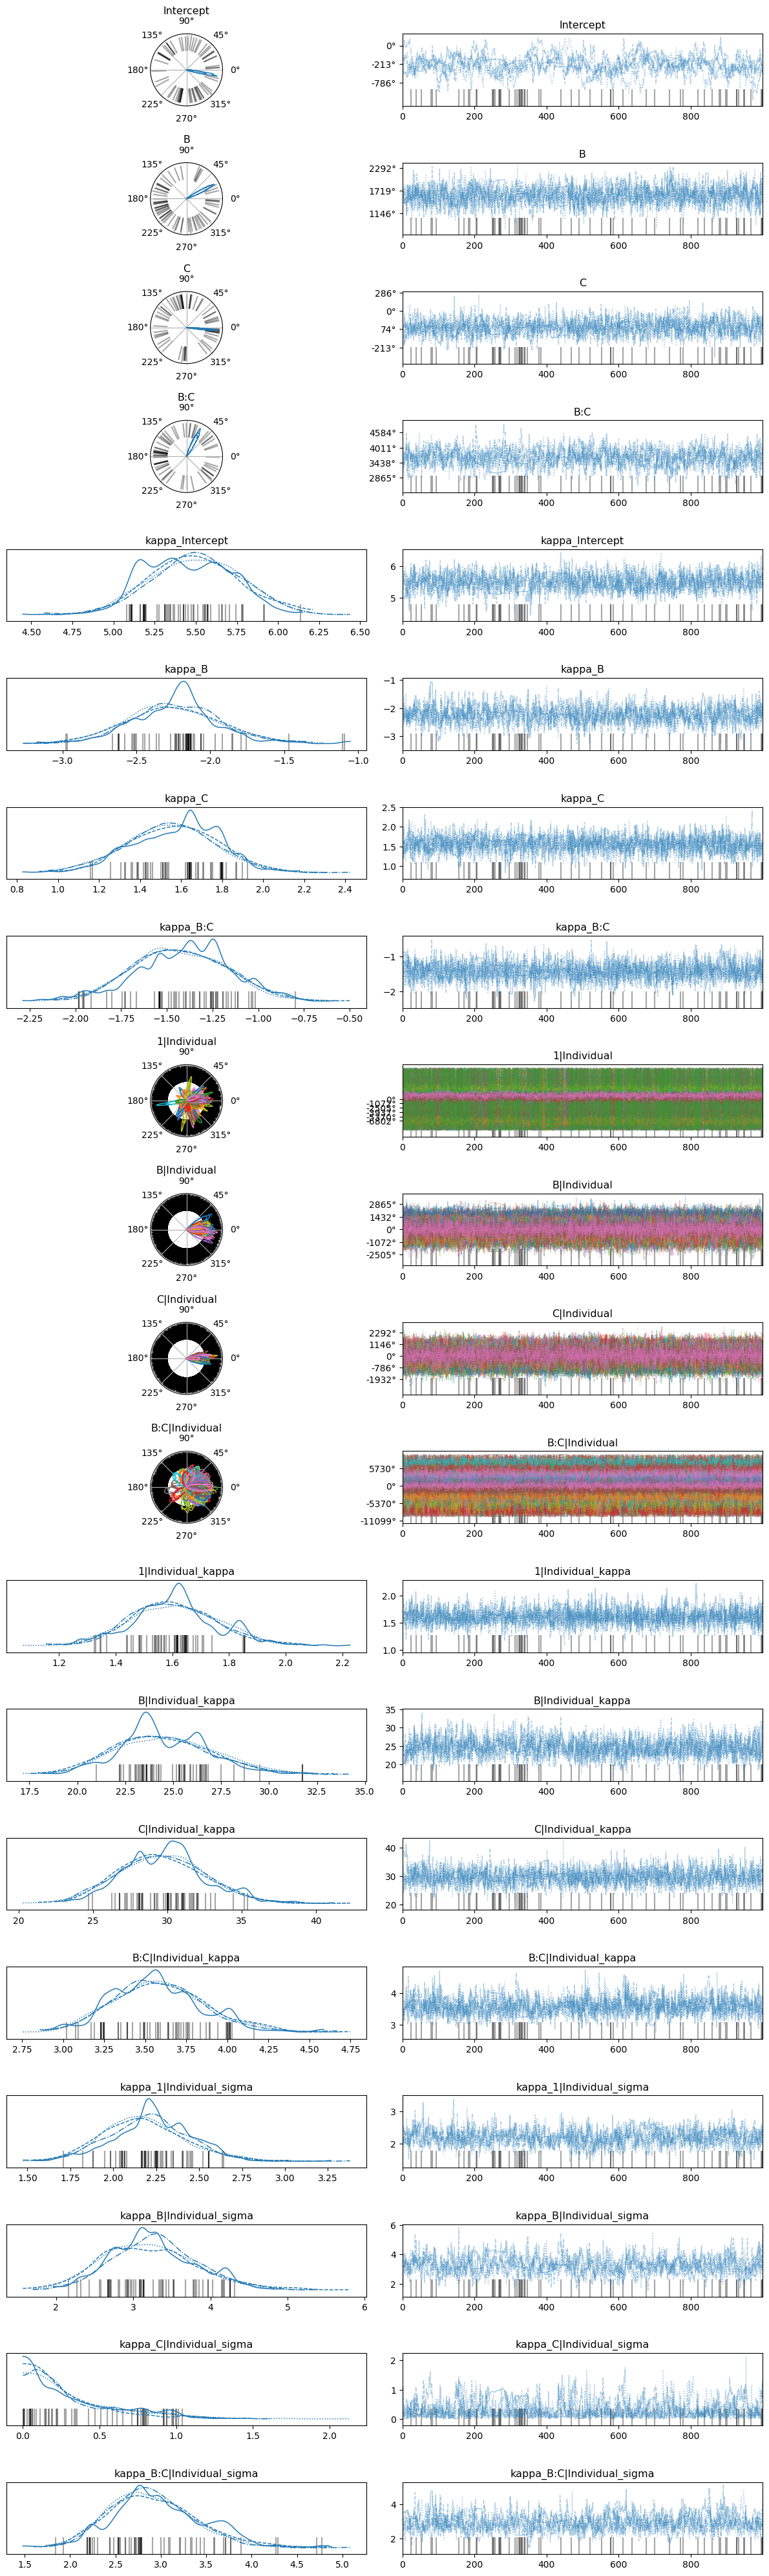

In [140]:
#Specify which parameters are circular
vars=[
        "Intercept",
        "B",
        "C",
        "B:C",
        "kappa_Intercept",
        "kappa_B",
        "kappa_C",
        "kappa_B:C",
        "1|Individual",
        "B|Individual",
        "C|Individual",
        "B:C|Individual",
        "1|Individual_kappa",
        "B|Individual_kappa",
        "C|Individual_kappa",
        "B:C|Individual_kappa",
        "kappa_1|Individual_sigma",
        "kappa_B|Individual_sigma",
        "kappa_C|Individual_sigma",
        "kappa_B:C|Individual_sigma",
       ]
cvars = ["Intercept",
        "B",
        "C",
        "B:C",
        "1|Individual",
        "B|Individual",
        "C|Individual",
        "B:C|Individual",
        ]
#transform the circular data for interpretability
idata_trans = idata.copy() # set up a variable for transformed data
for cvar in cvars:
    idata_trans.posterior[cvar] = -180*idata_trans.posterior[cvar]/np.pi # convert each to degrees that will plot clockwise

az.plot_trace(idata_trans,
              var_names= vars,
              circ_var_names=cvars,
              circ_var_units='degrees') #now in degrees and going clockwise, but axis labels are anticlock and start at right
plt.tight_layout()
plt.show()#without divergences takes about 30s

## Extract & inspect posterior samples

/var/folders/nq/smdrxv810_z_tfcmgmg5gkb00000gn/T/ipykernel_1653/2346096510.py:120: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  individual_circmean_gl  = shifted_modulo(circmean(headings_gl))
/var/folders/nq/smdrxv810_z_tfcmgmg5gkb00000gn/T/ipykernel_1653/2346096510.py:119: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  individual_circmean_gh = shifted_modulo(circmean(headings_gh))
/var/folders/nq/smdrxv810_z_tfcmgmg5gkb00000gn/T/ipykernel_1653/2346096510.py:121: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  individual_circmean_uh = shifted_modulo(circmean(headings_uh))
/var/folders/nq/smdrxv810_z_tfcmgmg5gkb00000gn/T/ipykernel_1653/2346096510.py:122: SmallSampleWarning: One or more sample a

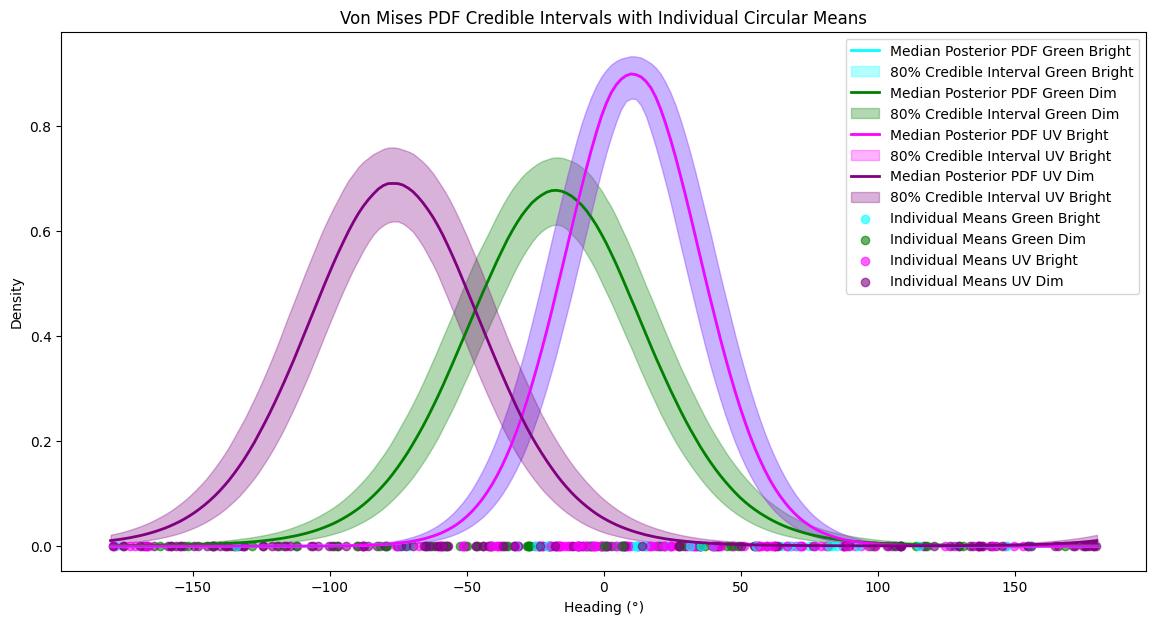

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises, circmean

# Import shifted_modulo and softplus from unwrap.link.numpy
from unwrap.link.numpy import shifted_modulo, softplus

# --------------------------------------------------
# Extract posterior samples for population-level parameters
# using the Bambi naming scheme with capitalized variable names.
# --------------------------------------------------
# For the μ-model (the main target):
mu_intercept = idata.posterior['Intercept'].values          # fixed intercept for μ
mu_slopeB    = idata.posterior['B'].values               # fixed slope for μ # Not working?
mu_slopeC    = idata.posterior['C'].values               # fixed slope for μ # Not the right name?
mu_slopeBC   = idata.posterior['B:C'].values               # fixed slope for μ

# For the κ-model:
kappa_intercept = idata.posterior['kappa_Intercept'].values    # fixed intercept for κ (linear predictor)
kappa_slopeB    = idata.posterior['kappa_B'].values        # fixed slope for κ (linear predictor)
kappa_slopeC    = idata.posterior['kappa_C'].values        # fixed slope for κ (linear predictor)
kappa_slopeBC   = idata.posterior['kappa_B:C'].values        # fixed slope for κ (linear predictor)

# --------------------------------------------------
# Prepare a grid for plotting the von Mises PDFs
# --------------------------------------------------
theta = np.linspace(-np.pi, np.pi, 200)
theta_deg = theta.copy()*180/np.pi

fig, ax = plt.subplots(figsize=(14, 7))

# Total number of posterior samples available.
num_samples = mu_intercept.flatten().shape[0]

# Compute population-level parameters for each condition.
mu_pop_gh_samples_all = shifted_modulo(mu_intercept.flatten())
mu_pop_gl_samples_all  = shifted_modulo((mu_intercept + mu_slopeB).flatten())
mu_pop_uh_samples_all  = shifted_modulo((mu_intercept + mu_slopeC).flatten())
mu_pop_ul_samples_all  = shifted_modulo((mu_intercept + mu_slopeB + mu_slopeC + mu_slopeBC).flatten())
kappa_pop_gh_samples_all = softplus(kappa_intercept.flatten())
kappa_pop_gl_samples_all  = softplus((kappa_intercept + kappa_slopeB).flatten())
kappa_pop_uh_samples_all  = softplus((kappa_intercept + kappa_slopeC).flatten())
kappa_pop_ul_samples_all  = softplus((kappa_intercept + kappa_slopeB + kappa_slopeC + kappa_slopeBC).flatten())

# --------------------------------------------------
# Compute the von Mises PDF for each posterior sample at each theta.
# The resulting arrays have shape (num_samples, len(theta)).
# --------------------------------------------------
pdf_gh = vonmises.pdf(
    theta[None, :],
    kappa=kappa_pop_gh_samples_all[:, None],
    loc=mu_pop_gh_samples_all[:, None]
)
pdf_gl = vonmises.pdf(
    theta[None, :],
    kappa=kappa_pop_gl_samples_all[:, None],
    loc=mu_pop_gl_samples_all[:, None]
)
pdf_uh = vonmises.pdf(
    theta[None, :],
    kappa=kappa_pop_uh_samples_all[:, None],
    loc=mu_pop_uh_samples_all[:, None]
)
pdf_ul = vonmises.pdf(
    theta[None, :],
    kappa=kappa_pop_ul_samples_all[:, None],
    loc=mu_pop_ul_samples_all[:, None]
)

# For each theta, compute the median and the 95% credible interval. #JJF this appears to be the 80%CI!
median_pdf_gh = np.median(pdf_gh, axis=0)
lower_pdf_gh  = np.percentile(pdf_gh, 10, axis=0)
upper_pdf_gh  = np.percentile(pdf_gh, 90, axis=0)

median_pdf_gl = np.median(pdf_gl, axis=0)
lower_pdf_gl  = np.percentile(pdf_gl, 10, axis=0)
upper_pdf_gl  = np.percentile(pdf_gl, 90, axis=0)

median_pdf_uh = np.median(pdf_gh, axis=0)
lower_pdf_uh  = np.percentile(pdf_gh, 10, axis=0)
upper_pdf_uh  = np.percentile(pdf_gh, 90, axis=0)

median_pdf_ul = np.median(pdf_ul, axis=0)
lower_pdf_ul  = np.percentile(pdf_ul, 10, axis=0)
upper_pdf_ul  = np.percentile(pdf_ul, 90, axis=0)

# --------------------------------------------------
# Plot the median PDFs and fill between the 95% credible intervals.
# --------------------------------------------------
ax.plot(theta_deg, median_pdf_gh, color='cyan', lw=2, label='Median Posterior PDF Green Bright')
ax.fill_between(theta_deg, lower_pdf_gh, upper_pdf_gh, color='cyan', alpha=0.3,
                label='80% Credible Interval Green Bright')

ax.plot(theta_deg, median_pdf_gl, color='green', lw=2, label='Median Posterior PDF Green Dim')
ax.fill_between(theta_deg, lower_pdf_gl, upper_pdf_gl, color='green', alpha=0.3,
                label='80% Credible Interval Green Dim')

ax.plot(theta_deg, median_pdf_uh, color='magenta', lw=2, label='Median Posterior PDF UV Bright')
ax.fill_between(theta_deg, lower_pdf_uh, upper_pdf_uh, color='magenta', alpha=0.3,
                label='80% Credible Interval UV Bright')

ax.plot(theta_deg, median_pdf_ul, color='purple', lw=2, label='Median Posterior PDF UV Dim')
ax.fill_between(theta_deg, lower_pdf_ul, upper_pdf_ul, color='purple', alpha=0.3,
                label='80% Credible Interval UV Bright')

# --------------------------------------------------
# Plot the circular means for each individual (individual-level summaries)
# --------------------------------------------------
for i, individual in enumerate(df['Individual'].unique()):
    individual_data = df[df['Individual'] == individual]
    
    # Get headings for Light Off (Light == 0) and Light On (Light == 1)
    headings_gh = individual_data.loc[(individual_data['B'] == 0) & (individual_data['C'] == 0), 'angle'].dropna()
    headings_gl = individual_data.loc[(individual_data['B'] == 1) & (individual_data['C'] == 0), 'angle'].dropna()
    headings_uh = individual_data.loc[(individual_data['B'] == 0) & (individual_data['C'] == 1), 'angle'].dropna()
    headings_ul = individual_data.loc[(individual_data['B'] == 1) & (individual_data['C'] == 1), 'angle'].dropna()
    
    # Compute circular means for this individual and wrap into [-π, π] using shifted_modulo.
    individual_circmean_gh = shifted_modulo(circmean(headings_gh))
    individual_circmean_gl  = shifted_modulo(circmean(headings_gl))
    individual_circmean_uh = shifted_modulo(circmean(headings_uh))
    individual_circmean_ul  = shifted_modulo(circmean(headings_ul))
    
    # Plot individual circular means.
    ax.scatter(individual_circmean_gh*180/np.pi, 0, color='cyan', alpha=0.6,
               label='Individual Means Green Bright' if i == 0 else "")
    ax.scatter(individual_circmean_gl*180/np.pi, 0, color='green', alpha=0.6,
               label='Individual Means Green Dim' if i == 0 else "")
    ax.scatter(individual_circmean_uh*180/np.pi, 0, color='magenta', alpha=0.6,
               label='Individual Means UV Bright' if i == 0 else "")
    ax.scatter(individual_circmean_ul*180/np.pi, 0, color='purple', alpha=0.6,
               label='Individual Means UV Dim' if i == 0 else "")

ax.set_title('Von Mises PDF Credible Intervals with Individual Circular Means')
ax.set_xlabel('Heading (°)')
ax.set_ylabel('Density')
ax.legend()
plt.show()